In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [102]:
df = pd.read_csv('./Telco-Customer-Churn.csv')

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [165]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Analyze output

In [170]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [174]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

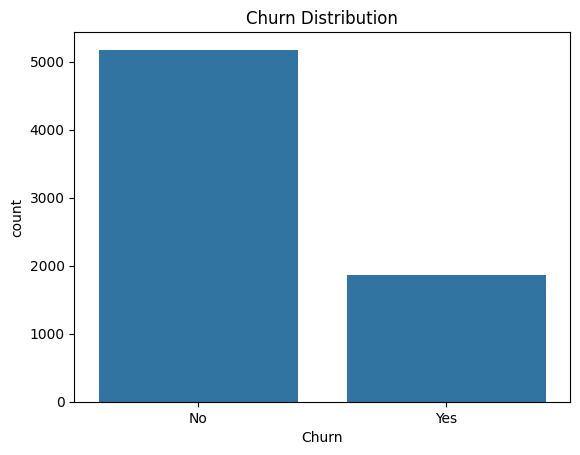

In [176]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

## Missing value check

In [178]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate value check

In [179]:
df.duplicated().sum()

np.int64(0)

## Categories check

- TotalCharges should be a numeric field
- customerID is an identifier and does not contain predictive signal, so it should not be used as a feature.

In [169]:
exclude_cols = ['customerID', 'TotalCharges'] 

for col in df.select_dtypes(include=['object']):
    if col not in exclude_cols:
        print("*******", col, "********* \n")
        print("Unique: ", df[col].unique())
        print("N-Unique: ", df[col].nunique())
        print(df[col].value_counts(), "\n")
    

******* gender ********* 

Unique:  ['Female' 'Male']
N-Unique:  2
gender
Male      3555
Female    3488
Name: count, dtype: int64 

******* Partner ********* 

Unique:  ['Yes' 'No']
N-Unique:  2
Partner
No     3641
Yes    3402
Name: count, dtype: int64 

******* Dependents ********* 

Unique:  ['No' 'Yes']
N-Unique:  2
Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

******* PhoneService ********* 

Unique:  ['No' 'Yes']
N-Unique:  2
PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

******* MultipleLines ********* 

Unique:  ['No phone service' 'No' 'Yes']
N-Unique:  3
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

******* InternetService ********* 

Unique:  ['DSL' 'Fiber optic' 'No']
N-Unique:  3
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

******* OnlineSecurity ********* 

Unique:  ['No' 'Yes' 'No internet service']
N-Unique: 

# Convresion to numeric type

In [180]:
df[df['TotalCharges'] == ' ']['TotalCharges'].count()

np.int64(11)

In [181]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [182]:
df['TotalCharges'].replace(' ', '0.0', inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18088\3381341631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].replace(' ', '0.0', inplace=True)


In [183]:
df['TotalCharges'] = df['TotalCharges'].astype('double')

In [184]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


## Crosstab analysis (categorical vs target)

### Strong signal

 - Contract - Single most important feature in the dataset. Customers on monthly contracts have no switching cost . They can leave anytime. Two year contract customers are locked in and rarely churn.

 - PaymentMethod - Electronic check customers churn the most by far. Automatic payment customers are more committed.

 - InternetService - One of the strongest features. Fiber optic customers are extremely dissatisfied - possibly due to high price, competition, or quality issues.

 - TechSupport - Customers without tech support feel unsupported and leave. Strong signal.

 - OnlineSecurity - Ignoring No internet service — customers without online security churn nearly 3x more. Strong signal.

 - PaperlessBilling - Paperless billing customers churn 2x more.


### Moderate signal

 - OnlineBackup - Meaningful gap - customers without backup churn more. Moderate signal.

 - DeviceProtection - Similar pattern to OnlineBackup - customers without protection are less engaged and more likely to leave.

 - Dependents - Customers with dependents are much more stable. Family responsibility = less likely to switch providers.

- Partner - Customers without a partner churn significantly more. Likely single customers feel less committed to keeping a family plan.


### Weak signal

 - StreamingMovies - Weak on its own. The apparent signal is borrowed from InternetService. 

 - StreamingTV - Small gap between No and Yes - weak predictor. Strong signal only comes from No internet service which is redundant with Internet services.

 - MultipleLines - Very small gap between No and Yes. No phone service is same group as PhoneService = No - redundant. Weak predictor overall.

 - PhoneService - Virtually no difference. No meaningful impact.

 - Gender - Almost identical churn rate. Gender has no predictive power.



In [200]:
exclude_cols = ['customerID', 'Churn'] 

for col in df.select_dtypes(include=['object']):
    if col not in exclude_cols:
        print(f"\n--- {col} vs Churn ---")
        print(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)


--- gender vs Churn ---
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

--- Partner vs Churn ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents vs Churn ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

--- PhoneService vs Churn ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

--- MultipleLines vs Churn ---
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

--- InternetService vs Churn ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber 

In [186]:
df[df['StreamingMovies'] == 'No internet service']['Churn'].value_counts(normalize=True)

Churn
No     0.92595
Yes    0.07405
Name: proportion, dtype: float64

In [187]:
df[df['InternetService'] == 'No']['Churn'].value_counts(normalize=True)

Churn
No     0.92595
Yes    0.07405
Name: proportion, dtype: float64

In [147]:
df[df['PhoneService'] == 'No']['Churn'].value_counts(normalize=True)

Churn
No     0.750733
Yes    0.249267
Name: proportion, dtype: float64

In [151]:
df[df['MultipleLines'] == 'No phone service']['Churn'].value_counts(normalize=True)

Churn
No     0.750733
Yes    0.249267
Name: proportion, dtype: float64

- PhoneService already contains this information. 
- It is safe to replace No phone service with No in all those columns

In [157]:
mask = (df['MultipleLines'] == 'No phone service') & (df['PhoneService'] != 'No')
print(f"Inconsistent rows: {df[mask].shape[0]}")

Inconsistent rows: 0



- InternetService already contains this information. 
- It is safe to replace No internet service with No in all those columns

In [149]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
        'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    mask = (df[col] == 'No internet service') & (df['InternetService'] != 'No')
    count = df[mask].shape[0]
    print(f"{col}: {count} inconsistent rows")

OnlineSecurity: 0 inconsistent rows
OnlineBackup: 0 inconsistent rows
DeviceProtection: 0 inconsistent rows
TechSupport: 0 inconsistent rows
StreamingTV: 0 inconsistent rows
StreamingMovies: 0 inconsistent rows


# Check distributions

In [188]:
for col in df.select_dtypes(exclude=['object']):
    print(col)

SeniorCitizen
tenure
MonthlyCharges
TotalCharges


## tenure

- Tenure shows a skewed distribution with a strong concentration of customers in the very early months (0–5 months).

- There is also a noticeable group of customers with very high tenure (around 65–72 months), indicating long-term users.

- Customers in the mid-tenure range (5–65 months) are more evenly distributed without a strong peak.

- This suggests the presence of two key groups: new customers and long-term loyal customers

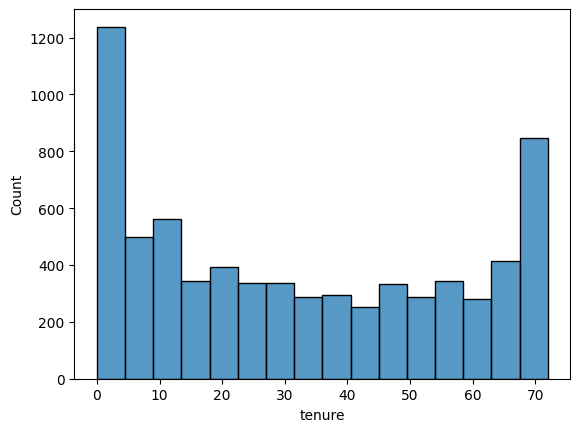

In [189]:
sns.histplot(df, x='tenure')
plt.show()


In [190]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

# MonthlyCharges

- This is a bimodal distribution with 2 peaks
- It shows two distinct customer groups low-paying and high-paying
- Most likely low paying customer use basic services and high paying customers use premium services

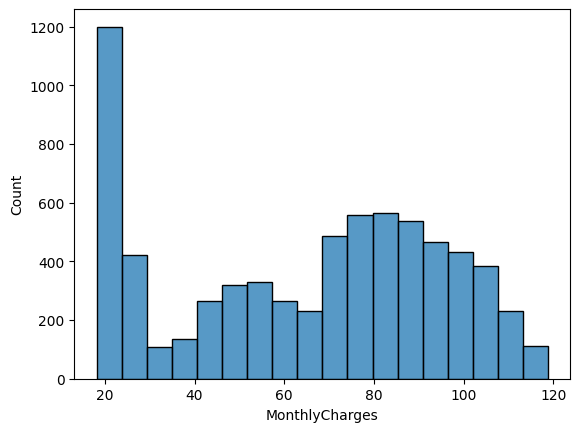

In [191]:
sns.histplot(df, x='MonthlyCharges')
plt.show()

In [192]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

# TotalCharges
 - Right-skewed distribution (positively skewed). Data is not normally distributed. Skewness can affect models like linear regression.

 - Most values are low (near 0–2000). Few values extend up to 8000+. 
 - Low total charges may indicate either customers with low monthly charges or customers with short tenure.
 - High total charges likely represent long-term or high-value customers.

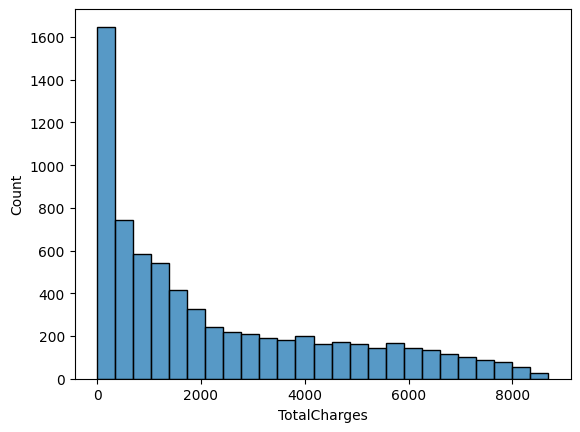

In [193]:
sns.histplot(df, x='TotalCharges')
plt.show()

In [194]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

## Co-relation between numeric features

- TotalCharges is strongly correlated with tenure and moderately correlated with MonthlyCharges, since it is derived from both.

- Including all three variables in a logistic regression model may introduce multicollinearity.

- While the model may still perform reasonably well, coefficient estimates may become unstable and harder to interpret.

In [195]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


<Axes: >

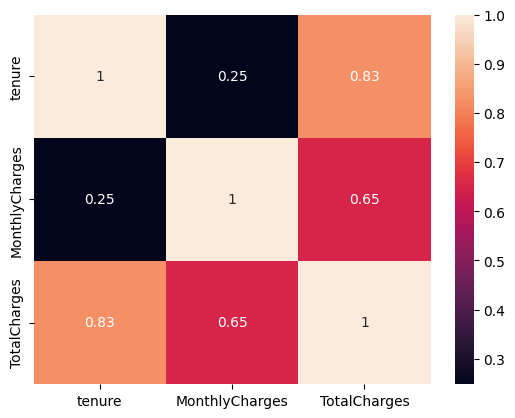

In [199]:
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True)

# Outlier detection

- Most individuals have tenure between about 10 and 55, with a typical value around 28. No visible outliers in the distribution.

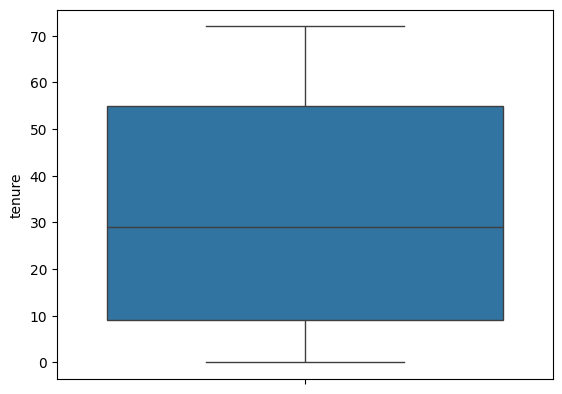

In [207]:
sns.boxplot(y=df['tenure'])
plt.show()

- Most customers have monthly charges between about 35 and 90, with a typical value around 70, and no visible outliers in the distribution.

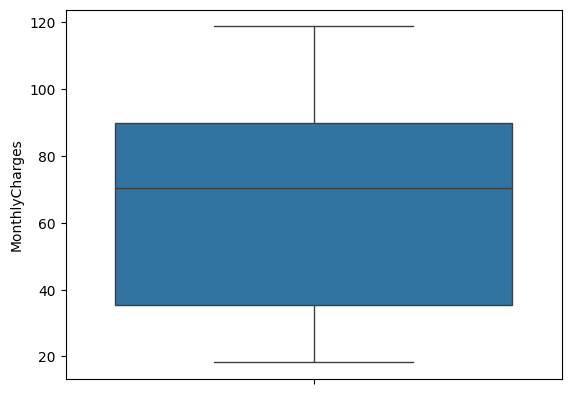

In [209]:
sns.boxplot(y=df['MonthlyCharges'])
plt.show()

- Most customers have total charges below ~3800, with a typical value around 1400, but there is a long tail of customers with very high total charges. No visible outliers in the distribution.

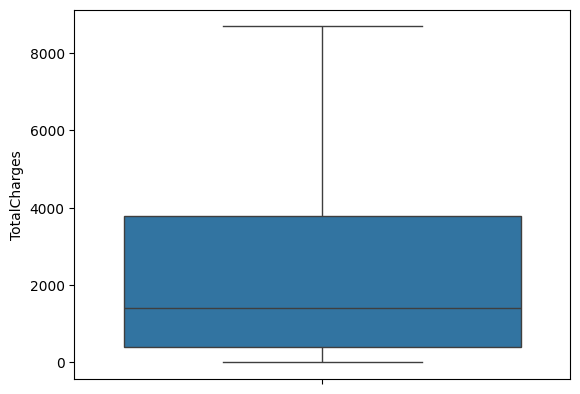

In [210]:
sns.boxplot(y=df['TotalCharges'])
plt.show()

## Numerical features vs target 

- Customers who churn tend to leave early, while long-tenure customers are significantly more stable—making early lifecycle engagement the most critical factor in retention

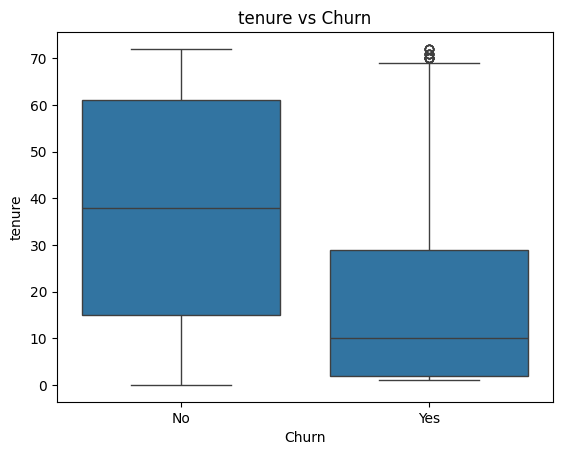

In [211]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title(f'tenure vs Churn')
plt.show()

- Customers who churned have a noticeably higher median monthly charge (around ~$80) compared to non-churners (around ~$60–65). This suggests that customers paying more are more likely to leave.

- A significant portion of non-churners fall in the lower price range (~$20–$40), indicating lower-cost plans may encourage customers to stay

- Both groups still overlap considerably, meaning monthly charges alone don’t fully explain churn—other factors likely matter too.

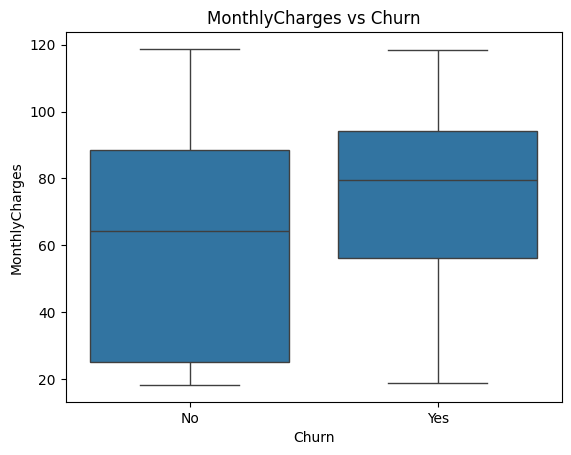

In [216]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges vs Churn')
plt.show()

- Total Charges is heavily tied to customer tenure. The plot suggests that churn is more common among newer or shorter-tenure customers, while long-term customers are much more likely to stay.

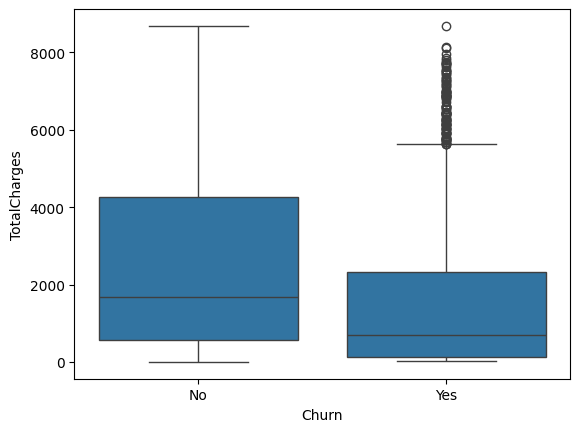

In [217]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.show("Total Charges vs Churn")
plt.show()